In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model=ChatGroq(model='qwen/qwen3.8-27b',max_tokens=999)

In [5]:
class LlmState(TypedDict):
   question:str
   answer:str 

In [6]:
def llm_q_a(state:LlmState) -> LlmState:
    
    #extract the question from the state
    question=state['question']
    
    #form a prompt
    prompt=f"Answer the following question {question} \n Important:Answer should not contain ** and ### "
    
    #ask qsn to llm
    answer=model.invoke(prompt).content
    
    #update the answer in state
    state['answer']=answer
    
    
    return state


In [7]:
#create graph 
graph=StateGraph(LlmState)

#create node
graph.add_node('llm_q_a',llm_q_a)

#create edge
graph.add_edge(START,'llm_q_a')
graph.add_edge('llm_q_a',END)

#compile graph

workflow=graph.compile()

In [8]:
#execute the graph
initial_state={'question':'What are the  10 famous desitanation of Nepal and Why  did tourist prefer to go there'}
final_state=workflow.invoke(initial_state)

In [9]:
final_state

{'question': 'What are the  10 famous desitanation of Nepal and Why  did tourist prefer to go there',
 'answer': "Nepal is renowned for its diverse landscapes, ranging from the majestic Himalayas to lush subtropical forests and ancient cultural sites. Here are ten famous destinations in Nepal and the reasons why tourists prefer to visit them.\n\n1. Kathmandu Valley\nKathmandu, along with its nearby cities Patan and Bhaktapur, is the cultural heart of Nepal. Tourists prefer this destination because it houses some of the most significant UNESCO World Heritage Sites, such as Swayambhunath, Boudhanath, and Pashupatinath. The valley offers a unique blend of Hindu and Buddhist traditions, vibrant street life, and a rich history of Newari architecture. It serves as the primary gateway for international travelers entering the country.\n\n2. Pokhara\nOften called the city of lakes, Pokhara is the second most popular destination in Nepal. It is preferred for its stunning views of the Annapurna a

In [10]:
print(final_state['answer'])

Nepal is renowned for its diverse landscapes, ranging from the majestic Himalayas to lush subtropical forests and ancient cultural sites. Here are ten famous destinations in Nepal and the reasons why tourists prefer to visit them.

1. Kathmandu Valley
Kathmandu, along with its nearby cities Patan and Bhaktapur, is the cultural heart of Nepal. Tourists prefer this destination because it houses some of the most significant UNESCO World Heritage Sites, such as Swayambhunath, Boudhanath, and Pashupatinath. The valley offers a unique blend of Hindu and Buddhist traditions, vibrant street life, and a rich history of Newari architecture. It serves as the primary gateway for international travelers entering the country.

2. Pokhara
Often called the city of lakes, Pokhara is the second most popular destination in Nepal. It is preferred for its stunning views of the Annapurna and Dhaulagiri mountain ranges, which are clearly visible on clear days. The serene environment of Phewa Lake, the advent

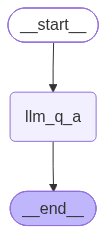

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())